<a href="https://colab.research.google.com/github/mayssajr/eHealthChain/blob/main/Facial_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [4]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/BaseMayssa/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",

)

Found 2799 files belonging to 2 classes.


In [5]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/BaseMayssa/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
)

Found 138 files belonging to 2 classes.


In [6]:
cnn = tf.keras.models.Sequential()

**Couches principales de CNN pour l'extraction des caracteristiques des images**


* **Couche de convolution** permet d'appliquer des filtres pour extraire les caracteristiques de l'entrees
* **maxpooling**: reduit la dimension spaciale des caracteristiques en concervant uniquement les valeurs maximales dans des regions specifiques



In [7]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu',input_shape=[64,64,3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [9]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

**Couche qui evite le surapprentissage**

In [10]:
cnn.add(tf.keras.layers.Dropout(0.5))

**Couche qui applatit les donnees d'entrees (convertit les fonctionnalités des images en un vecteur)**

In [11]:
cnn.add(tf.keras.layers.Flatten())

In [12]:
cnn.add(tf.keras.layers.Dense(units=128,activation='relu'))

In [13]:
cnn.add(tf.keras.layers.Dense(units=2,activation='softmax'))

In [14]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [15]:
training_history = cnn.fit(x=training_set,validation_data=test_set,epochs=20)

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1500s 17s/step - accuracy: 0.6817 - loss: 7.9167 - val_accuracy: 0.9348 - val_loss: 0.2751
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 34s 118ms/step - accuracy: 0.9149 - loss: 0.2199 - val_accuracy: 0.8986 - val_loss: 0.2619
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.9051 - loss: 0.2371 - val_accuracy: 0.8696 - val_loss: 0.2914
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.9321 - loss: 0.1778 - val_accuracy: 0.8841 - val_loss: 0.2829
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.9481 - loss: 0.1355 - val_accuracy: 0.9565 - val_loss: 0.1257
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.9472 - loss: 0.1341 - val_accuracy: 0.9420 - val_loss: 0.1642
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.9594 - loss: 0.0941 - val_accuracy: 0.9710 - val_loss: 0.1184
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.9735 - loss: 0.0853 - val_accu

# Nouvelle section

In [16]:
cnn.save("trained_model.h5")

In [17]:
#Recording History
import json
with open('training_hist.json', 'w') as f:
    json.dump(training_history.history, f)

In [18]:
training_history.history

{'accuracy': [0.7777777910232544,
  0.9196141362190247,
  0.8946052193641663,
  0.9367631077766418,
  0.943551242351532,
  0.9442657828330994,
  0.9592711925506592,
  0.9682029485702515,
  0.9657020568847656,
  0.9764201641082764,
  0.9789210557937622,
  0.9824937582015991,
  0.9696320295333862,
  0.9707038402557373,
  0.980350136756897,
  0.9764201641082764,
  0.9921400547027588,
  0.986066460609436,
  0.9717756509780884,
  0.9578421115875244],
 'loss': [2.4364054203033447,
  0.2102464884519577,
  0.26206740736961365,
  0.1639092117547989,
  0.14409540593624115,
  0.1449386328458786,
  0.10347390919923782,
  0.09126336872577667,
  0.09758567810058594,
  0.0777597725391388,
  0.06048417091369629,
  0.04786533862352371,
  0.07939201593399048,
  0.07447545230388641,
  0.05949113890528679,
  0.06747390329837799,
  0.02723759599030018,
  0.038014840334653854,
  0.08187974989414215,
  0.1190497949719429],
 'val_accuracy': [0.9347826242446899,
  0.8985507488250732,
  0.8695651888847351,
  0.

In [19]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [20]:
print('Test set Accuracy: {} %'.format(training_history.history['val_accuracy'][-1]*100))

Test set Accuracy: 97.826087474823 %


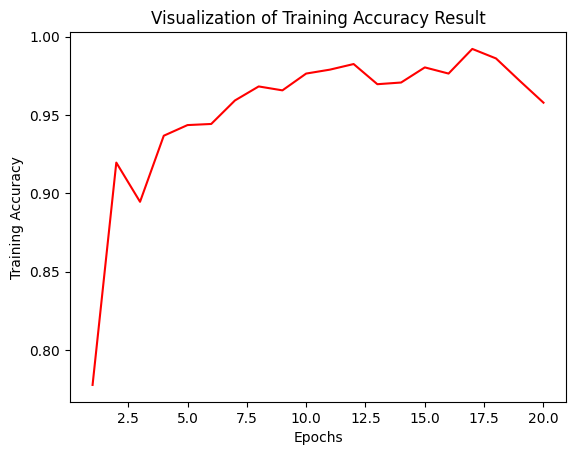

In [21]:
epochs=[i for i in range(1,21)]
plt.plot(epochs,training_history.history['accuracy'],color='red')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.title("Visualization of Training Accuracy Result")
plt.show()

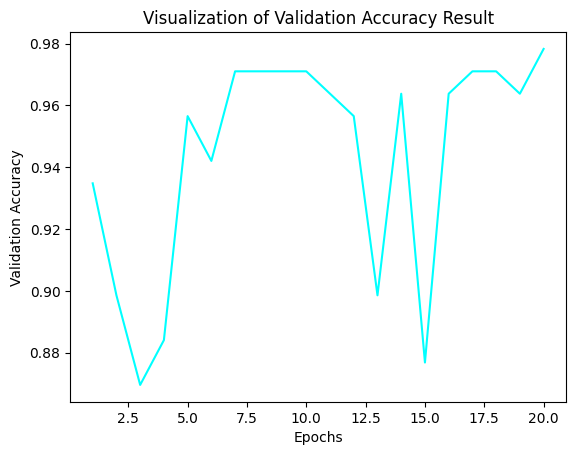

In [22]:
plt.plot(epochs,training_history.history['val_accuracy'],color='cyan')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title("Visualization of Validation Accuracy Result")
plt.show()

In [23]:
cnn = tf.keras.models.load_model('/content/trained_model.h5')

In [24]:
classe_name=training_set.class_names
classe_name

['Mayssa', 'Not_Mayssa']

88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step


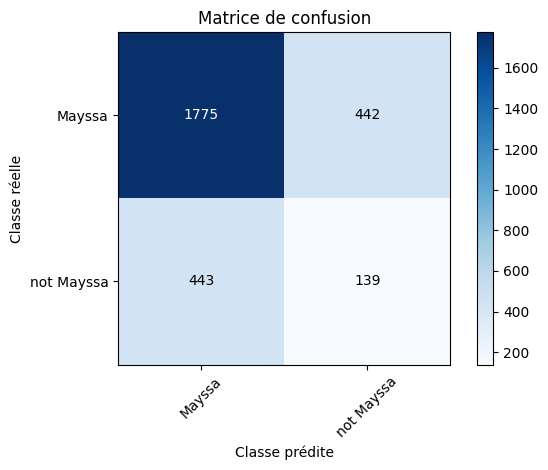

In [25]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Charger le modèle entraîné
cnn = tf.keras.models.load_model('trained_model.h5')

# Prédire les classes des images de test
y_pred = cnn.predict(training_set)
y_pred = np.argmax(y_pred, axis=1)  # Convertir les probabilités en classes prédites

# Obtenir les vraies classes des images de test
y_true = np.concatenate([y for x, y in training_set], axis=0)
y_true = np.argmax(y_true, axis=1)  # Convertir les vecteurs de classes en classes

# Définir les noms de classes
class_names = ['Mayssa', 'not Mayssa']  # Remplacez par les noms de vos propres classes

# Calculer la matrice de confusion
confusion_mat = confusion_matrix(y_true, y_pred)

# Afficher la matrice de confusion avec les noms de classes
plt.imshow(confusion_mat, cmap=plt.cm.Blues)
plt.title('Matrice de confusion')
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

thresh = confusion_mat.max() / 2.
for i in range(confusion_mat.shape[0]):
    for j in range(confusion_mat.shape[1]):
        plt.text(j, i, format(confusion_mat[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if confusion_mat[i, j] > thresh else "black")

plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.tight_layout()
plt.show()

In [26]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/BaseMayssa/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 138 files belonging to 2 classes.


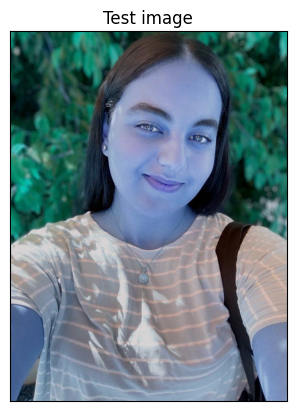

In [48]:
import cv2
image_path= '/content/drive/MyDrive/manel.jpg'
img=cv2.imread(image_path)
plt.imshow(img)
plt.title('Test image')
plt.xticks([])
plt.yticks([])
plt.show()


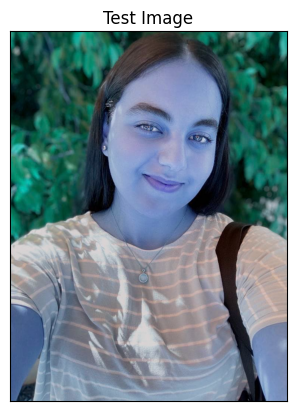

In [49]:
import cv2

# Displaying the image
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [50]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(64,64))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [43]:
#test_set.class_names
print(predictions)

[[0.05053262 0.94946736]]


In [51]:
result_index = np.where(predictions[0] == max(predictions[0]))
print(result_index)

(array([1]),)


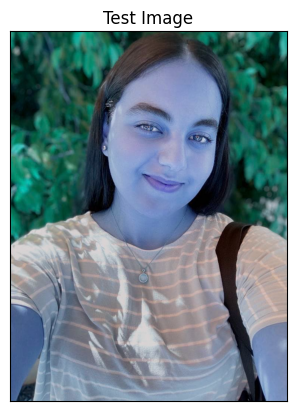

In [52]:
# Displaying the image
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [46]:
print("She is  {}".format(test_set.class_names[result_index[0][0]]))

She is  Not_Mayssa
